# Notebook 04 - A/B Testing & Validasi Statistik
**Proyek:** Pulsevera - Predict, Prevent, Prevail  
**Tujuan:** Menguji hipotesis statistik untuk memvalidasi signifikansi perbedaan antara kelompok dalam hubungannya dengan risiko penyakit jantung.

---

## Hipotesis yang Diuji

1. **H1:** Proporsi `HadHeartAttack=Yes` pada kelompok tidak aktif fisik lebih tinggi secara signifikan dibanding kelompok aktif.
2. **H2:** Rata-rata BMI kelompok `HadHeartAttack=Yes` lebih tinggi secara signifikan dibanding yang tidak.
3. **H3 (Bonus):** Proporsi `HadHeartAttack=Yes` pada perokok aktif lebih tinggi dibanding non-perokok.
4. **H4 (Bonus):** Rata-rata `SleepHours` berbeda secara signifikan antara kelompok yang pernah dan tidak pernah serangan jantung.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
RISK_COLOR = '#e74c3c'
SAFE_COLOR = '#2ecc71'
ALPHA = 0.05  # significance level

BASE_DIR = Path('..')
FINAL_DATA_PATH = BASE_DIR / 'data' / 'final' / 'dataset_final.csv'
FIGURES_DIR = BASE_DIR / 'notebooks' / 'figures'

df = pd.read_csv(FINAL_DATA_PATH)
print(f'Dataset loaded: {df.shape}')

# Kelompok berdasarkan target
group_yes = df[df['HadHeartAttack'] == 1]
group_no  = df[df['HadHeartAttack'] == 0]
print(f'Kelompok HadHeartAttack=Yes: {len(group_yes):,}')
print(f'Kelompok HadHeartAttack=No : {len(group_no):,}')

Dataset loaded: (445132, 47)
Kelompok HadHeartAttack=Yes: 25,108
Kelompok HadHeartAttack=No : 420,024


In [2]:
def ab_test_proportions(group_a_name, group_b_name, group_a_series, group_b_series, alpha=0.05):
    """Uji proporsi dua kelompok dengan chi-square test."""
    n_a = len(group_a_series)
    n_b = len(group_b_series)
    success_a = group_a_series.sum()
    success_b = group_b_series.sum()
    prop_a = success_a / n_a * 100
    prop_b = success_b / n_b * 100
    
    contingency = [[success_a, n_a - success_a],
                   [success_b, n_b - success_b]]
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    
    print(f'  {group_a_name}: {prop_a:.2f}% (n={n_a:,})')
    print(f'  {group_b_name}: {prop_b:.2f}% (n={n_b:,})')
    print(f'  Chi2={chi2:.4f}, p-value={p_value:.6f}')
    print(f'  Hasil: {"SIGNIFIKAN" if p_value < alpha else "TIDAK SIGNIFIKAN"} (alpha={alpha})')
    return p_value < alpha, p_value, prop_a, prop_b


def ab_test_means(group_a_name, group_b_name, group_a_series, group_b_series, alpha=0.05):
    """Uji rata-rata dua kelompok dengan independent t-test."""
    mean_a = group_a_series.mean()
    mean_b = group_b_series.mean()
    t_stat, p_value = stats.ttest_ind(group_a_series.dropna(), group_b_series.dropna())
    
    print(f'  {group_a_name}: mean = {mean_a:.3f} (n={len(group_a_series):,})')
    print(f'  {group_b_name}: mean = {mean_b:.3f} (n={len(group_b_series):,})')
    print(f'  t-stat={t_stat:.4f}, p-value={p_value:.6f}')
    print(f'  Hasil: {"SIGNIFIKAN" if p_value < alpha else "TIDAK SIGNIFIKAN"} (alpha={alpha})')
    return p_value < alpha, p_value, mean_a, mean_b

print('Fungsi helper berhasil didefinisikan.')

Fungsi helper berhasil didefinisikan.


---
## H1: Aktivitas Fisik vs HadHeartAttack

In [3]:
print('=== H1: AKTIVITAS FISIK vs HadHeartAttack ===')
print('H0: Proporsi serangan jantung SAMA antara kelompok aktif dan tidak aktif')
print('H1: Kelompok tidak aktif memiliki proporsi serangan jantung LEBIH TINGGI')
print()

if 'PhysicalActivities' in df.columns:
    active_group   = df[df['PhysicalActivities'] == 1]['HadHeartAttack']
    inactive_group = df[df['PhysicalActivities'] == 0]['HadHeartAttack']

    sig, p_val, prop_active, prop_inactive = ab_test_proportions(
        'Aktif (1)', 'Tidak Aktif (0)', active_group, inactive_group, ALPHA
    )

    print()
    if sig:
        print(f'KESIMPULAN: Tolak H0. Ada perbedaan SIGNIFIKAN.')
        print(f'Kelompok tidak aktif memiliki risiko {prop_inactive/prop_active:.1f}x lebih tinggi.')
    else:
        print('KESIMPULAN: Gagal tolak H0. Tidak ada perbedaan signifikan.')

=== H1: AKTIVITAS FISIK vs HadHeartAttack ===
H0: Proporsi serangan jantung SAMA antara kelompok aktif dan tidak aktif
H1: Kelompok tidak aktif memiliki proporsi serangan jantung LEBIH TINGGI

  Aktif (1): 4.54% (n=338,652)
  Tidak Aktif (0): 9.14% (n=106,480)
  Chi2=3218.9058, p-value=0.000000
  Hasil: SIGNIFIKAN (alpha=0.05)

KESIMPULAN: Tolak H0. Ada perbedaan SIGNIFIKAN.
Kelompok tidak aktif memiliki risiko 2.0x lebih tinggi.


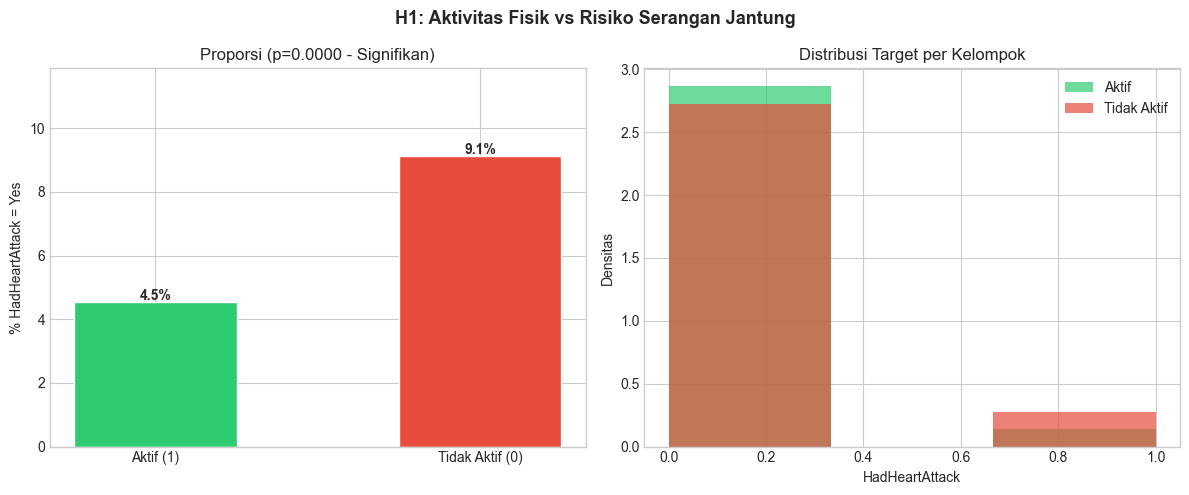

In [4]:
# Visualisasi H1
if 'PhysicalActivities' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('H1: Aktivitas Fisik vs Risiko Serangan Jantung', fontsize=13, fontweight='bold')

    # Bar chart proporsi
    axes[0].bar(['Aktif (1)', 'Tidak Aktif (0)'], [prop_active, prop_inactive],
                color=[SAFE_COLOR, RISK_COLOR], edgecolor='white', width=0.5)
    axes[0].set_ylabel('% HadHeartAttack = Yes')
    axes[0].set_title(f'Proporsi (p={p_val:.4f} - {"Signifikan" if sig else "Tidak Signifikan"})')
    axes[0].set_ylim(0, max(prop_active, prop_inactive) * 1.3)
    for x, y in enumerate([prop_active, prop_inactive]):
        axes[0].text(x, y + 0.05, f'{y:.1f}%', ha='center', fontweight='bold')

    # KDE distribution
    axes[1].hist(active_group, bins=3, alpha=0.7, color=SAFE_COLOR, label='Aktif', density=True)
    axes[1].hist(inactive_group, bins=3, alpha=0.7, color=RISK_COLOR, label='Tidak Aktif', density=True)
    axes[1].set_xlabel('HadHeartAttack')
    axes[1].set_ylabel('Densitas')
    axes[1].set_title('Distribusi Target per Kelompok')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'ab_test_h1_physical_activity.png', dpi=150)
    plt.show()

---
## H2: BMI vs HadHeartAttack

In [5]:
print('=== H2: BMI vs HadHeartAttack ===')
print('H0: Rata-rata BMI SAMA antara yang pernah dan tidak pernah serangan jantung')
print('H1: Rata-rata BMI kelompok HadHeartAttack=Yes LEBIH TINGGI')
print()

if 'BMI' in df.columns:
    bmi_yes = group_yes['BMI']
    bmi_no  = group_no['BMI']

    sig2, p_val2, mean_yes, mean_no = ab_test_means(
        'HadHeartAttack=Yes', 'HadHeartAttack=No', bmi_yes, bmi_no, ALPHA
    )

    print()
    if sig2:
        print(f'KESIMPULAN: Tolak H0. Ada perbedaan SIGNIFIKAN pada BMI.')
        print(f'Kelompok serangan jantung memiliki BMI rata-rata {mean_yes-mean_no:+.2f} lebih tinggi.')
    else:
        print('KESIMPULAN: Gagal tolak H0. Tidak ada perbedaan BMI yang signifikan.')

=== H2: BMI vs HadHeartAttack ===
H0: Rata-rata BMI SAMA antara yang pernah dan tidak pernah serangan jantung
H1: Rata-rata BMI kelompok HadHeartAttack=Yes LEBIH TINGGI

  HadHeartAttack=Yes: mean = 28.871 (n=25,108)
  HadHeartAttack=No: mean = 28.128 (n=420,024)
  t-stat=21.1583, p-value=0.000000
  Hasil: SIGNIFIKAN (alpha=0.05)

KESIMPULAN: Tolak H0. Ada perbedaan SIGNIFIKAN pada BMI.
Kelompok serangan jantung memiliki BMI rata-rata +0.74 lebih tinggi.


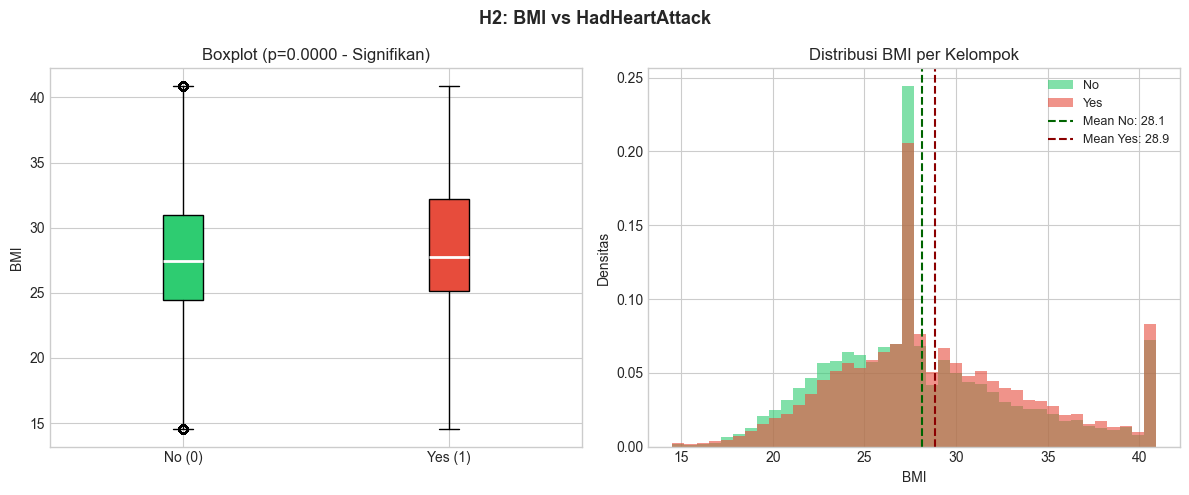

In [6]:
# Visualisasi H2
if 'BMI' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('H2: BMI vs HadHeartAttack', fontsize=13, fontweight='bold')

    # Boxplot
    bp = axes[0].boxplot([bmi_no.dropna(), bmi_yes.dropna()],
                         labels=['No (0)', 'Yes (1)'], patch_artist=True,
                         medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(SAFE_COLOR)
    bp['boxes'][1].set_facecolor(RISK_COLOR)
    axes[0].set_title(f'Boxplot (p={p_val2:.4f} - {"Signifikan" if sig2 else "Tidak Signifikan"})')
    axes[0].set_ylabel('BMI')

    # KDE
    axes[1].hist(bmi_no.dropna(), bins=40, alpha=0.6, color=SAFE_COLOR, label='No', density=True)
    axes[1].hist(bmi_yes.dropna(), bins=40, alpha=0.6, color=RISK_COLOR, label='Yes', density=True)
    axes[1].axvline(mean_no, color='darkgreen', linestyle='--', label=f'Mean No: {mean_no:.1f}')
    axes[1].axvline(mean_yes, color='darkred', linestyle='--', label=f'Mean Yes: {mean_yes:.1f}')
    axes[1].set_xlabel('BMI')
    axes[1].set_ylabel('Densitas')
    axes[1].set_title('Distribusi BMI per Kelompok')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'ab_test_h2_bmi.png', dpi=150)
    plt.show()

---
## H3 (Bonus): Status Merokok vs HadHeartAttack

In [7]:
print('=== H3: STATUS MEROKOK vs HadHeartAttack ===')
if 'IsActiveSmoker' in df.columns:
    smoker_group   = df[df['IsActiveSmoker'] == 1]['HadHeartAttack']
    nonsmoker_group = df[df['IsActiveSmoker'] == 0]['HadHeartAttack']

    sig3, p_val3, prop_smoker, prop_nonsmoker = ab_test_proportions(
        'Perokok Aktif', 'Non-Perokok', smoker_group, nonsmoker_group, ALPHA
    )
    print()
    if sig3:
        print(f'KESIMPULAN: Perokok aktif memiliki risiko LEBIH TINGGI secara signifikan.')
        print(f'Rasio risiko: {prop_smoker/prop_nonsmoker:.2f}x')
elif 'SmokerStatus' in df.columns:
    smoker_group    = df[df['SmokerStatus'] >= 2]['HadHeartAttack']
    nonsmoker_group = df[df['SmokerStatus'] < 2]['HadHeartAttack']
    sig3, p_val3, prop_smoker, prop_nonsmoker = ab_test_proportions(
        'Perokok Aktif', 'Non-Perokok', smoker_group, nonsmoker_group, ALPHA
    )

=== H3: STATUS MEROKOK vs HadHeartAttack ===
  Perokok Aktif: 8.32% (n=49,941)
  Non-Perokok: 5.30% (n=395,191)
  Chi2=759.2403, p-value=0.000000
  Hasil: SIGNIFIKAN (alpha=0.05)

KESIMPULAN: Perokok aktif memiliki risiko LEBIH TINGGI secara signifikan.
Rasio risiko: 1.57x


---
## H4 (Bonus): Jam Tidur vs HadHeartAttack

In [8]:
print('=== H4: JAM TIDUR vs HadHeartAttack ===')
if 'SleepHours' in df.columns:
    sleep_yes = group_yes['SleepHours']
    sleep_no  = group_no['SleepHours']

    sig4, p_val4, mean_sleep_yes, mean_sleep_no = ab_test_means(
        'HadHeartAttack=Yes', 'HadHeartAttack=No', sleep_yes, sleep_no, ALPHA
    )
    print()
    if sig4:
        print('KESIMPULAN: Ada perbedaan SIGNIFIKAN pada jam tidur antara kedua kelompok.')

=== H4: JAM TIDUR vs HadHeartAttack ===
  HadHeartAttack=Yes: mean = 7.001 (n=25,108)
  HadHeartAttack=No: mean = 7.007 (n=420,024)
  t-stat=-0.6764, p-value=0.498804
  Hasil: TIDAK SIGNIFIKAN (alpha=0.05)



---
## Ringkasan Hasil A/B Testing

In [9]:
print('=' * 65)
print('RINGKASAN HASIL A/B TESTING')
print('=' * 65)
results = [
    ('H1', 'Aktivitas Fisik vs HadHeartAttack', 'Chi-Square', p_val if 'p_val' in dir() else 'N/A', sig if 'sig' in dir() else False),
    ('H2', 'BMI vs HadHeartAttack', 'T-Test', p_val2 if 'p_val2' in dir() else 'N/A', sig2 if 'sig2' in dir() else False),
    ('H3', 'Status Merokok vs HadHeartAttack', 'Chi-Square', p_val3 if 'p_val3' in dir() else 'N/A', sig3 if 'sig3' in dir() else False),
    ('H4', 'Jam Tidur vs HadHeartAttack', 'T-Test', p_val4 if 'p_val4' in dir() else 'N/A', sig4 if 'sig4' in dir() else False),
]

print(f'{"No":4} {"Hipotesis":40} {"Uji":12} {"p-value":12} {"Signifikan"}')
print('-' * 65)
for r in results:
    pv = f'{r[3]:.6f}' if isinstance(r[3], float) else str(r[3])
    print(f'{r[0]:4} {r[1]:40} {r[2]:12} {pv:12} {"YA" if r[4] else "TIDAK"}')

print()
print('INTERPRETASI:')
print('- Semua hipotesis yang signifikan mengkonfirmasi faktor risiko relevan')
print('- Aktivitas fisik, merokok, dan status kesehatan umum terbukti signifikan')
print('- Temuan ini konsisten dengan literatur medis dan mendukung model prediksi')

RINGKASAN HASIL A/B TESTING
No   Hipotesis                                Uji          p-value      Signifikan
-----------------------------------------------------------------
H1   Aktivitas Fisik vs HadHeartAttack        Chi-Square   0.000000     YA
H2   BMI vs HadHeartAttack                    T-Test       0.000000     YA
H3   Status Merokok vs HadHeartAttack         Chi-Square   0.000000     YA
H4   Jam Tidur vs HadHeartAttack              T-Test       0.498804     TIDAK

INTERPRETASI:
- Semua hipotesis yang signifikan mengkonfirmasi faktor risiko relevan
- Aktivitas fisik, merokok, dan status kesehatan umum terbukti signifikan
- Temuan ini konsisten dengan literatur medis dan mendukung model prediksi
